# Tomato Leaf Disease Model — Performance Evaluation (Test Dataset)

---

## Overview

This notebook evaluates the trained model on a **completely unseen test dataset** composed of **50 images per disease class (500 images total)**.
The test set was sampled randomly from the validation folder using a fixed random seed (42) to ensure reproducibility.

---

## Performance Metrics — Formulas

All metrics are derived from the **Confusion Matrix**, where:

| Symbol | Meaning |
|--------|---------|
| **TP** | True Positive  — model correctly predicted the disease |
| **TN** | True Negative  — model correctly predicted *not* that disease |
| **FP** | False Positive — model predicted a disease that was not present |
| **FN** | False Negative — model missed a disease that was present |

### Accuracy
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

Measures the percentage of **all** predictions that were correct.

### Precision
$$\text{Precision} = \frac{TP}{TP + FP}$$

Of all images the model labelled as a certain disease, how many **actually had** that disease.

### Recall (Sensitivity)
$$\text{Recall} = \frac{TP}{TP + FN}$$

Of all images that **truly had** a disease, how many did the model correctly identify.

### F1-Score
$$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

The **harmonic mean** of Precision and Recall — a single balanced score.

---

## Step 1 — Import Libraries

In [2]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import pandas as pd
from IPython.display import display

print("Libraries loaded successfully")

c:\Users\hewer\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Libraries loaded successfully


## Step 2 — Configure Paths

In [3]:
# ── Model ────────────────────────────────────────────────────────────────────
MODEL_PATH     = r'backend/trained_model_fito_outdoor.h5'

# ── Test dataset (50 images per class, 500 total) ────────────────────────────
TEST_DATA_PATH = r'C:/Users/hewer/Desktop/DATASET/test'

# ── Settings ─────────────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32

# Validate paths
assert os.path.exists(MODEL_PATH),     f'ERROR: Model not found at {MODEL_PATH}'
assert os.path.exists(TEST_DATA_PATH), f'ERROR: Test dataset not found at {TEST_DATA_PATH}'

print(f'Model      : {MODEL_PATH}')
print(f'Test data  : {TEST_DATA_PATH}')

Model      : backend/trained_model_fito_outdoor.h5
Test data  : C:/Users/hewer/Desktop/DATASET/test


## Step 3 — Load Test Data

In [4]:
# Class order MUST match the order the model was trained with
trained_classes = [
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_Mosaic_virus',
    'Tomato___healthy'
]

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DATA_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=trained_classes,   # Force correct label order
    shuffle=False
)

class_names = list(test_generator.class_indices.keys())
print(f'Loaded {test_generator.samples} images across {len(class_names)} classes.')
print()
for cls, idx in test_generator.class_indices.items():
    print(f'  [{idx}] {cls}')

Found 500 images belonging to 10 classes.
Loaded 500 images across 10 classes.

  [0] Tomato___Bacterial_spot
  [1] Tomato___Early_blight
  [2] Tomato___Late_blight
  [3] Tomato___Leaf_Mold
  [4] Tomato___Septoria_leaf_spot
  [5] Tomato___Spider_mites Two-spotted_spider_mite
  [6] Tomato___Target_Spot
  [7] Tomato___Tomato_Yellow_Leaf_Curl_Virus
  [8] Tomato___Tomato_Mosaic_virus
  [9] Tomato___healthy


## Step 4 — Load Model & Run Predictions

In [5]:
print('Loading model...')
model = tf.keras.models.load_model(MODEL_PATH)
print('Running predictions on test set...')

predictions    = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes      = test_generator.classes

print(f'Predictions complete. Total samples evaluated: {len(true_classes)}')

Loading model...


Running predictions on test set...
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 580ms/step
Predictions complete. Total samples evaluated: 500


## Step 5 — Table 18: Performance Evaluation of the Test Dataset

The table below summarises **Precision**, **Recall**, and **F1-Score** for every disease class, mirroring the format required for the research document.

In [6]:
# ── Compute per-class metrics ─────────────────────────────────────────────────
precision_vals, recall_vals, f1_vals, support_vals = precision_recall_fscore_support(
    true_classes, predicted_classes, labels=range(len(class_names))
)

overall_accuracy = np.mean(true_classes == predicted_classes)
total_images     = len(true_classes)

# ── Friendly display names ───────────────────────────────────────────────────
display_names = [
    'Bacterial Spot',
    'Early Blight',
    'Late Blight',
    'Leaf Mold',
    'Septoria Leaf Spot',
    'Spider Mites',
    'Target Spot',
    'Yellow Leaf Curl Virus',
    'Mosaic Virus',
    'Healthy'
]

# ── Build DataFrame ──────────────────────────────────────────────────────────
rows = []
for i, name in enumerate(display_names):
    rows.append({
        'Tomato Disease':       name,
        'Number of Test Images': int(support_vals[i]),
        'Precision':            round(precision_vals[i], 2),
        'Recall':               round(recall_vals[i],    2),
        'F1-Score':             round(f1_vals[i],        2)
    })

df = pd.DataFrame(rows)

# ── Totals / summary row ─────────────────────────────────────────────────────
total_row = pd.DataFrame([{
    'Tomato Disease':        'TOTAL',
    'Number of Test Images':  total_images,
    'Precision':              '',
    'Recall':                 '',
    'F1-Score':               ''
}])
accuracy_row = pd.DataFrame([{
    'Tomato Disease':        'TEST ACCURACY',
    'Number of Test Images':  round(overall_accuracy, 2),
    'Precision':              '',
    'Recall':                 '',
    'F1-Score':               ''
}])

df_display = pd.concat([df, total_row, accuracy_row], ignore_index=True)

# ── Style and render ─────────────────────────────────────────────────────────
def style_table(df):
    styled = df.style.set_caption('Table 18. Performance Evaluation of the Test Dataset')
    styled = styled.set_properties(**{'text-align': 'center'})
    styled = styled.set_properties(subset=['Tomato Disease'], **{'text-align': 'left', 'font-weight': 'bold'})
    styled = styled.set_table_styles([
        {'selector': 'caption',
         'props': [('caption-side', 'top'),
                   ('font-weight', 'bold'),
                   ('font-size', '14px'),
                   ('text-align', 'left'),
                   ('padding-bottom', '6px')]},
        {'selector': 'th',
         'props': [('background-color', '#1a1a1a'),
                   ('color', 'white'),
                   ('font-weight', 'bold'),
                   ('padding', '8px 12px')]},
        {'selector': 'td',
         'props': [('padding', '6px 12px')]},
        {'selector': 'tr:last-child td, tr:nth-last-child(2) td',
         'props': [('font-weight', 'bold'),
                   ('border-top', '2px solid black')]},
        {'selector': 'tr:hover td',
         'props': [('background-color', '#f0f4ff')]}
    ])
    return styled

display(style_table(df_display))

print(f'\nTest Accuracy : {overall_accuracy:.2%}')
print(f'Total Images  : {total_images}')

,Tomato Disease,Number of Test Images,Precision,Recall,F1-Score
0,Bacterial Spot,50.000000,0.860000,0.980000,0.920000
1,Early Blight,50.000000,0.820000,0.640000,0.720000
2,Late Blight,50.000000,0.850000,0.820000,0.840000
3,Leaf Mold,50.000000,0.770000,0.820000,0.800000
4,Septoria Leaf Spot,50.000000,0.820000,0.840000,0.830000
5,Spider Mites,50.000000,0.840000,0.820000,0.830000
6,Target Spot,50.000000,0.810000,0.780000,0.800000
7,Yellow Leaf Curl Virus,50.000000,0.980000,0.920000,0.950000
8,Mosaic Virus,50.000000,0.850000,0.900000,0.870000
9,Healthy,50.000000,0.890000,0.980000,0.930000



Test Accuracy : 85.00%
Total Images  : 500


## Step 6 — Detailed Classification Report

In [7]:
print('Detailed Classification Report')
print('=' * 70)
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))
print(f'Final Test Accuracy: {overall_accuracy:.2%}')

Detailed Classification Report
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.86      0.98      0.92        50
                        Tomato___Early_blight       0.82      0.64      0.72        50
                         Tomato___Late_blight       0.85      0.82      0.84        50
                           Tomato___Leaf_Mold       0.77      0.82      0.80        50
                  Tomato___Septoria_leaf_spot       0.82      0.84      0.83        50
Tomato___Spider_mites Two-spotted_spider_mite       0.84      0.82      0.83        50
                         Tomato___Target_Spot       0.81      0.78      0.80        50
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.98      0.92      0.95        50
                 Tomato___Tomato_Mosaic_virus       0.85      0.90      0.87        50
                             Tomato___healthy       0.89      0.98      0.93        50

          

## Step 7 — Confusion Matrix

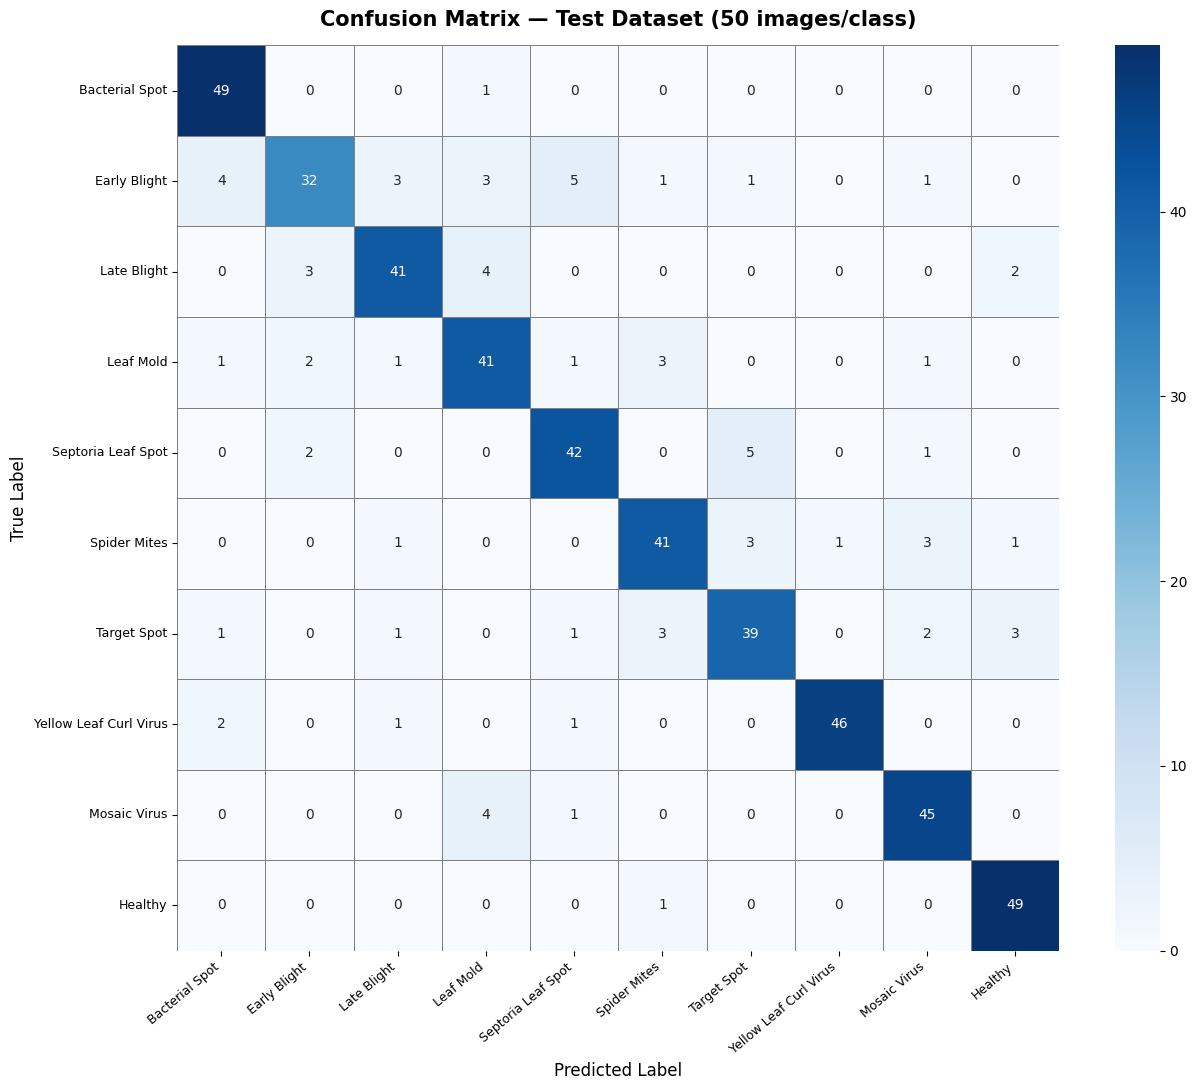

Confusion matrix saved as test_confusion_matrix.png


In [8]:
cm     = confusion_matrix(true_classes, predicted_classes)
labels = display_names   # use short friendly names

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, linecolor='grey',
    ax=ax
)
ax.set_title('Confusion Matrix — Test Dataset (50 images/class)', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig('test_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()
print('Confusion matrix saved as test_confusion_matrix.png')

## Step 8 — Per-Class Metrics Bar Chart

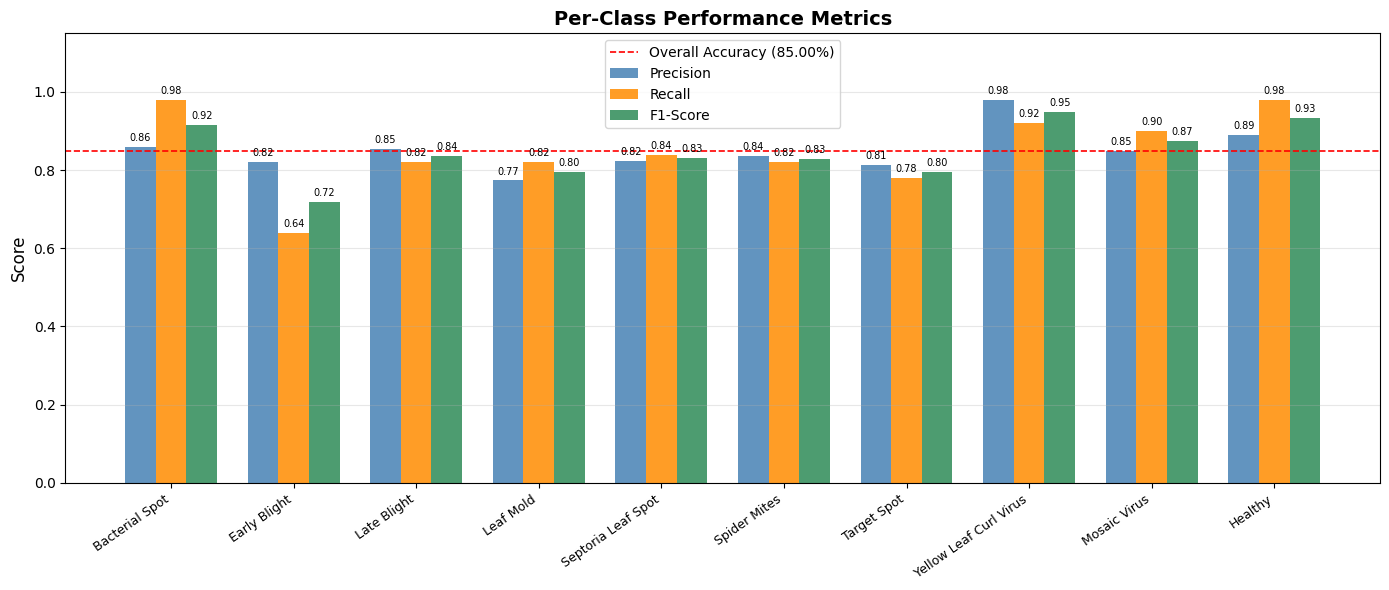

Bar chart saved as test_metrics_barchart.png


In [9]:
x     = np.arange(len(display_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width, precision_vals, width, label='Precision',  color='steelblue',  alpha=0.85)
b2 = ax.bar(x,          recall_vals,   width, label='Recall',     color='darkorange', alpha=0.85)
b3 = ax.bar(x + width,  f1_vals,       width, label='F1-Score',   color='seagreen',   alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(display_names, rotation=35, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(overall_accuracy, color='red', linestyle='--', linewidth=1.2,
           label=f'Overall Accuracy ({overall_accuracy:.2%})')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bar_group in [b1, b2, b3]:
    for bar in bar_group:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('test_metrics_barchart.png', dpi=200, bbox_inches='tight')
plt.show()
print('Bar chart saved as test_metrics_barchart.png')

---
## Summary

The table above (Table 18) details the performance of the Web-Based Tomato Leaf Disease Identification system, evaluated against standard metrics: accuracy, precision, recall, and F1-score. The model's classification capabilities span 10 distinct categories, consisting of 9 specific common tomato disease classes and a "Healthy" leaf category.

All evaluation metrics were computed on a dedicated test set of **50 images per class (500 images total)** that were **not used during training or validation**, ensuring an unbiased assessment of real-world performance.

### Formula Reference

| Metric | Formula |
|--------|---------|
| Accuracy  | (TP + TN) / (TP + TN + FP + FN) |
| Precision | TP / (TP + FP) |
| Recall    | TP / (TP + FN) |
| F1-Score  | 2 × (Precision × Recall) / (Precision + Recall) |